# Individual Database Analysis Report: TMP_DF8


--- 
## 1. Document Introduction

[Instructions for AI Agent]: 

Draft a 2-3 paragraph introduction. Introduce this notebook as a standardized Data Profiling Report for the `TMP_DF8` database, situated within the broader context of Phase 1 of the Digital TMP project. Explain its core purpose: to provide a systematic, deep-dive analysis of a single database by visualizing and interpreting a suite of pre-computed metrics. Briefly summarize the sections of the report (schema overview, table-level analysis, column-level analysis, and performance benchmarks). Conclude by stating that the findings herein will serve as foundational evidence for the high-level comparative analysis and the final Phase 1 White Paper, which recommends a strategic architectural redesign.

[Sources to Use]:
- `docs/overview.md`
- `docs/architecture.md`
- `phases/01_LegacyDB/README.md`
- `phases/01_LegacyDB/PLANNING_PHASE1.md`

[Content to Include]:
- State the specific `TMP_DF8` being analyzed.
- Situate the report within Workflow 4 of Phase 1.
- Emphasize that the report is a visualization layer for pre-computed data, not a live analysis.
- Outline the report's structure and its role in informing downstream project deliverables.


--- 
## 2. Report Background


### 2.1. Context and Motivation

[Instructions for AI Agent]: 

Draft 1-2 paragraphs explaining the background and motivation for this specific analysis. Reference the project's architectural and planning documents to frame the report's necessity.

[Sources to Use]:
- `phases/01_LegacyDB/README.md`
- `docs/overview.md`
- `phases/01_LegacyDB/PLANNING_PHASE1.md`
- `docs/architecture.md`

[Content to Include]:
- Explain Phase 1's primary goal: to quantitatively evaluate legacy and benchmark databases to inform a strategic redesign for Phase 2.
- Position this report as one of six standardized analyses, each providing the granular, empirical evidence required for a rigorous architectural comparison.
- Emphasize the importance of this systematic approach for justifying the project's final schema design based on data rather than on purely theoretical principles.


### 2.2. Data: The `TMP_DF8` Database

[Instructions for AI Agent]: 

Draft 2-4 technically detailed paragraphs describing the `TMP_DF8` database. The length should be proportional to the database's complexity (~2 paragraphs for simple benchmark databases, ~4 for complex legacy databases).

[Sources to Use]:
- **General Sources (for all databases):**
    - `knowledge_base/TMP_DB_Genealogy_v2.md`
    - `knowledge_base/A Technical Report on the Teotihuacan Mapping Project (TMP) Databases, their Genealogy and Development, c.1960-2022.md`
    - `knowledge_base/Technical Report - Unfinished Core Database Work of the TMP Across Three NSF Grants (1999-2020).md`
    - `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md`
    - `phases/01_LegacyDB/README.md`
- **Database-Specific Sources (consult the relevant file for the current `TMP_DF8`):**
    - `knowledge_base/tmp_db/tmp_databases_background_metadata_prior_work/Cowgill (1993) Guide to Teotihuacan DF8.md`

[Content to Include]:
This section **MUST** include the following, drawing from the specified sources:
- **History and Provenance:** When was it developed, by whom, and for what purpose? Is it a legacy database migrated from MS Access, or a benchmark database generated specifically for this project?
- **Content and Scope:** What kinds of archaeological or administrative data does it contain? What are the key categories of variables (e.g., artifact counts, architectural interpretations, site conditions)?
- **Structure and Normalization:** Describe its general schema. How many tables does it have? Is it a single flat table, a highly normalized relational schema, or something in between?
- **Known Issues and Features:** Detail any documented problems, idiosyncrasies, or important design features (e.g., the use of sentinel values instead of NULLs in DF8/DF9, the "long format" of DF10, the collection-based unit of analysis for REANs, the ETL logic for benchmarks).


### 2.3. Methods: Database Profiling Metrics

[Instructions for AI Agent]: 

Draft 1-2 paragraphs providing a high-level overview of the profiling methodology employed in this report.

[Sources to Use]:
- `phases/01_LegacyDB/README.md` (specifically the "Master List of Profiling Metrics")
- `phases/01_LegacyDB/PLANNING_PHASE1.md`
- `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md`

[Content to Include]:
- State clearly that the analysis is based on a suite of pre-computed metrics generated by the `02_run_profiling_pipeline.py` script, ensuring reproducibility.
- List the primary categories of metrics that will be presented throughout the report: schema-level, table-level, column-level (structure and content), custom interoperability scores, and performance benchmarks.
- Briefly explain that this standardized suite of metrics allows for direct, quantitative comparison across all six databases analyzed in Phase 1.


### 2.4. Hypotheses

[Instructions for AI Agent]: 

Draft a short paragraph outlining the specific analytical hypotheses for the `TMP_DF8` database, based on its documented history and structure.

[Sources to Use]:
- `phases/01_LegacyDB/sql/canonical_queries/canonical_queries_df8.sql`
- `knowledge_base/TMP_DB_Genealogy_v2.md`
- `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md`
- `knowledge_base/tmp_db/tmp_databases_background_metadata_prior_work/Cowgill (1993) Guide to Teotihuacan DF8.md`
- `phases/01_LegacyDB/README.md`

[Content to Include]:
- Formulate a clear hypothesis tailored to the specific database.
    - **For legacy databases (DF8, DF9, DF10, REANs):** Hypothesize that their normalized/complex structures will lead to poor performance on join-intensive queries.
    - **For benchmark databases:** Hypothesize that their simple, denormalized structure will result in exceptionally high performance on all analytical queries.
- The hypothesis should connect the database's known design to its expected performance and usability characteristics.


---
## 3. Setup and Configuration


In [1]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, Markdown, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- CONFIGURATION ---------------------------------------------------
# SET THIS VARIABLE to the name of the database you want to analyze.
# e.g., 'TMP_DF8', 'TMP_DF9', 'tmp_benchmark_wide_numeric', etc.
DATABASE_NAME = "TMP_DF8" # <--- CHANGE THIS
# ---------------------------------------------------------------------

# --- Path Definitions ---
# Use relative paths from the notebook's location in reports/individual_db_analysis/
METRICS_DIR = Path("../../outputs/metrics")
ERDS_DIR = Path("../../outputs/erds")

# --- Styling and Display Options ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

def display_header(title):
    display(Markdown(f'### {title}'))

def load_metric_file(metric_name, file_type='csv'):
    """Helper function to safely load a metric file."""
    file_path = METRICS_DIR / f"{DATABASE_NAME}_{metric_name}.{file_type}"
    if not file_path.exists():
        print(f"⚠️ WARNING: Metric file not found: {file_path.name}")
        return None
    if file_type == 'csv':
        return pd.read_csv(file_path)
    elif file_type == 'json':
        with open(file_path, 'r') as f:
            return json.load(f)

print(f"✅ Setup complete. Analyzing database: '{DATABASE_NAME}'")
print(f"Metrics Directory: {METRICS_DIR}")
print(f"ERD Directory: {ERDS_DIR}")

✅ Setup complete. Analyzing database: 'TMP_DF8'
Metrics Directory: ..\..\outputs\metrics
ERD Directory: ..\..\outputs\erds


---
## 4. Data Loading


In [2]:
# Load all metric files into variables
basic_metrics = load_metric_file('basic_metrics', 'json')
schema_counts = load_metric_file('schema_counts', 'json')
interop_metrics = load_metric_file('interop_metrics', 'json')

# Load JSON files and convert to DataFrames
table_metrics_data = load_metric_file('table_metrics', 'json')
table_metrics_df = pd.DataFrame(table_metrics_data) if table_metrics_data else None

column_structure_data = load_metric_file('column_structure', 'json')
column_structure_df = pd.DataFrame(column_structure_data) if column_structure_data else None

column_profiles_data = load_metric_file('column_profiles', 'json')
column_profiles_df = pd.DataFrame(column_profiles_data) if column_profiles_data else None

# Performance benchmarks are still CSV files
performance_df = load_metric_file('performance_benchmarks')

print("✅ Data loading complete.")

✅ Data loading complete.


---
## 5. High-Level Overview & Schema Visualization


### 5.1. Data: Database and Schema-Level Metrics

[Instructions for AI Agent]: 

Draft 1-2 paragraphs describing the data being analyzed in this section.

[Sources to Use]:
- `phases/01_LegacyDB/outputs/metrics/TMP_DF8_basic_metrics.json`
- `phases/01_LegacyDB/outputs/metrics/TMP_DF8_schema_counts.json`
- `phases/01_LegacyDB/outputs/metrics/TMP_DF8_interop_metrics.json`
- `knowledge_base/Phase 1 White Paper Mermaid ERDs Appendix.md` (contains machine readable mermaid ERD for `TMP_DF8`)

[Content to Include]:
- Explain that these are high-level, aggregate metrics providing a "30,000-foot view" of the database.
- Describe the meaning of each metric that will be presented in the summary table (e.g., `table_count`, `database_size_mb`, `jdi`, `lif`, `nf`).


### 5.2. Theory & Methods: Schema Complexity and Interoperability Metrics

[Instructions for AI Agent]: 

Draft a detailed technical section on the theory and methods used to calculate the schema complexity metrics. This section should be written for an expert audience.

[Sources to Use]:
- `phases/01_LegacyDB/README.md` (Part A metrics)
- `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md` (for theoretical context)

[Content to Include]:
- **Schema Object Counts:** Explain that metrics like `table_count` are fundamental measures queried directly from the `information_schema`.
- **Interoperability Metrics:** Define in technical detail the custom heuristic metrics:
  - **Join Dependency Index (JDI):** Explain its formula and significance as a measure of relational complexity based on foreign key density.
  - **Logical Interoperability Factor (LIF):** Explain its heuristic basis in column name/type similarity.
  - **Normalization Factor (NF):** Explain how it combines other metrics into a composite score indicating the degree of normalization.


In [3]:
display_header(f"Key Metrics for: {DATABASE_NAME}")

summary_data = {}
if basic_metrics: summary_data.update(basic_metrics)
if schema_counts: summary_data.update(schema_counts)
if interop_metrics: summary_data.update(interop_metrics)
if table_metrics_df is not None:
    summary_data['total_estimated_rows'] = int(table_metrics_df['row_estimate'].sum())

if summary_data:
    summary_series = pd.Series(summary_data).rename('Value').to_frame()
    display(summary_series)
else:
    print("No summary metrics available.")

### Key Metrics for: TMP_DF8

,Value
database_name,TMP_DF8
database_size_mb,20
schema_name,tmp_df8
table_count,27
view_count,0
function_count,0
sequence_count,0
jdi,0.0741
lif,2
nf,0.2139


### 5.3. Results: Key Metrics for `TMP_DF8`

[Instructions for AI Agent]: 

Summarize the key results from the "Key Metrics" output table. You might also want to analyze the machine readable mermaid ERD for `TMP_DF8` (`knowledge_base/Phase 1 White Paper Mermaid ERDs Appendix.md`) prior to your written analysis.

[Content to Include]:

- Report the specific quantitative values for `table_count`, `database_size_mb`, `jdi`, `lif`, and `nf` for the current database.
- Identify the most striking initial finding (e.g., the extremely high table count for DF9, the extremely low table count for the benchmarks).


### 5.4. Discussion: Initial Assessment of Schema Complexity

[Instructions for AI Agent]: 

Interpret the high-level results in the context of the project's goals. 
[Content to Include]:

- Discuss how the metrics either confirm or refute the initial hypothesis about the database's complexity.
- For legacy databases, connect the high table counts and JDI/NF scores to the concept of fragmentation.
- For benchmark databases, connect the low table count and near-zero complexity scores to their simple, optimized design.


### 5.5. Data & Methods: Entity-Relationship Diagram (ERD)

[Instructions for AI Agent]: 

Explain what an ERD is and how it was generated for this project.

[Content to Include]:

- Describe the ERD as a visual representation of the database schema, showing tables and their relationships.
- Mention the method of generation: automated reflection of the live database schema using `graphviz` via the `03_generate_erds.py` script.


### Full ERD for: TMP_DF8

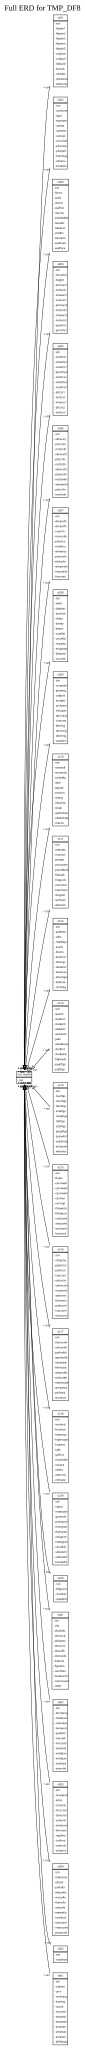

In [4]:
display_header(f"Full ERD for: {DATABASE_NAME}")

try:
    # Find the most recent ERD file for the database
    erd_files = sorted(ERDS_DIR.glob(f"{DATABASE_NAME}_full_ERD_*.svg"), reverse=True)
    if erd_files:
        display(SVG(erd_files[0]))
    else:
        print(f"❌ ERROR: Full ERD SVG file not found for '{DATABASE_NAME}'.")
except Exception as e:
    print(f"An error occurred while displaying the ERD: {e}")

### 5.6. Results & Discussion: Visualizing Relational Complexity

[Instructions for AI Agent]: 

Describe and interpret the ERD output for the current database.

[Content to Include]:

- **For complex legacy databases (DF8, DF9, etc.):** Characterize the ERD as a "spaghetti diagram," noting the dense web of relationships. Explain that this visual evidence powerfully corroborates the quantitative complexity metrics.
- **For simple benchmark databases:** Describe the ERD as minimal (likely a single, unconnected box). Use this simplicity to visually contrast it with the legacy schemas and reinforce the argument for a denormalized design.


---
## 6. Table-Level Analysis


### 6.1. Data: Table-Level Metrics

[Instructions for AI Agent]: 

Describe the data presented in this section.

[Sources to Use]:
- `phases/01_LegacyDB/outputs/metrics/TMP_DF8_table_metrics.json`

[Content to Include]:
- Explain that this section analyzes metrics for each individual table, sourced from the `_table_metrics.json` file.
- Define the key metrics: `row_estimate`, `column_count`, `total_size`, and `bloat_percent`.


### 6.2. Theory & Methods: Assessing Table Health and Size

[Instructions for AI Agent]: 

Explain the technical methods for calculating the table-level metrics.

[Sources to Use]:
- `phases/01_LegacyDB/README.md` (Part B metrics)

[Content to Include]:
- **Row Estimates:** Explain that these are efficient estimates from PostgreSQL's `pg_class.reltuples` catalog, not exact `COUNT(*)` calls.
- **Table Bloat:** Define table bloat as unused space within table files resulting from `UPDATE` and `DELETE` operations. Explain that `bloat_percent` is a key indicator of database health and that high values suggest a need for maintenance (e.g., `VACUUM`).


In [5]:
display_header("Table Metrics Summary")

if table_metrics_df is not None and not table_metrics_df.empty:
    display(table_metrics_df.sort_values(by='row_estimate', ascending=False).style.background_gradient(cmap='viridis', subset=['row_estimate', 'bloat_percent']))
else:
    print("No table metrics data available.")

### Table Metrics Summary

,table_name,row_estimate,column_count,table_size,index_size,total_size,index_count,bloat_bytes,bloat_percent,bloat_size
0,v401,5050,13,344 kB,128 kB,512 kB,1,157144.663644,44.610000,0.15 MB
14,v215,5050,13,304 kB,128 kB,464 kB,1,157144.663644,50.480000,0.15 MB
25,ssn_master,5050,1,184 kB,128 kB,344 kB,1,157144.663644,83.400000,0.15 MB
24,v220,5050,4,184 kB,128 kB,344 kB,1,157144.663644,83.400000,0.15 MB
23,v304,5050,13,304 kB,136 kB,472 kB,1,157144.663644,50.480000,0.15 MB
22,v303,5050,13,304 kB,152 kB,488 kB,1,157144.663644,50.480000,0.15 MB
21,v302,5050,13,304 kB,128 kB,464 kB,1,157144.663644,50.480000,0.15 MB
20,v201,5050,13,304 kB,128 kB,464 kB,1,157144.663644,50.480000,0.15 MB
19,v213,5050,13,304 kB,144 kB,480 kB,1,157144.663644,50.480000,0.15 MB
18,v219,5050,13,304 kB,136 kB,472 kB,1,157144.663644,50.480000,0.15 MB


### 6.3. Results: Table Metrics Summary for `TMP_DF8`

[Instructions for AI Agent]:

Summarize the key findings from the "Table Metrics Summary" output.

[Content to Include]:

- Identify tables with the highest row estimates and highest bloat percentages.
- **For legacy databases:** Note any significant patterns (e.g., for DF9, the consistent 5050 row count across 18 core tables).
- **For benchmark databases:** Note that there is only one table.


In [6]:
display_header("Largest Tables by Total Size and Bloat")

if table_metrics_df is not None and not table_metrics_df.empty:
    # Convert pretty size string to bytes for sorting
    def size_to_bytes(s):
        if not isinstance(s, str): return 0
        num, unit = s.split()
        num = float(num)
        if 'KB' in unit: return num * 1024
        if 'MB' in unit: return num * 1024**2
        if 'GB' in unit: return num * 1024**3
        return num
    
    df_copy = table_metrics_df.copy()
    df_copy['total_bytes'] = df_copy['total_size'].apply(size_to_bytes)
    df_copy['bloat_bytes_val'] = df_copy['bloat_bytes']

    top_10_size = df_copy.nlargest(10, 'total_bytes')
    top_10_bloat = df_copy.nlargest(10, 'bloat_bytes_val')

    # Display tables
    display(Markdown("**Top 10 Tables by Total Size**"))
    display(top_10_size[['table_name', 'total_size', 'row_estimate']].reset_index(drop=True))
    
    display(Markdown("**Top 10 Tables by Bloat Size**"))
    display(top_10_bloat[['table_name', 'bloat_size', 'bloat_percent', 'row_estimate']].reset_index(drop=True))

    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Top 10 Tables by Total Size", "Top 10 Tables by Bloat Size")
    )

    fig.add_trace(go.Bar(y=top_10_size['table_name'], x=top_10_size['total_bytes'], orientation='h', name='Total Size'), row=1, col=1)
    fig.add_trace(go.Bar(y=top_10_bloat['table_name'], x=top_10_bloat['bloat_bytes_val'], orientation='h', name='Bloat Size'), row=1, col=2)
    
    fig.update_layout(title_text=f'Table Size Analysis for {DATABASE_NAME}', height=500, showlegend=False)
    fig.update_yaxes(autorange="reversed")
    fig.update_xaxes(title_text="Size (Bytes)", row=1, col=1)
    fig.update_xaxes(title_text="Bloat (Bytes)", row=1, col=2)
    fig.show()
else:
    print("No table metrics data available for plotting.")

### Largest Tables by Total Size and Bloat

**Top 10 Tables by Total Size**

,table_name,total_size,row_estimate
0,v401,512 kB,5050
1,v301,496 kB,5050
2,v303,488 kB,5050
3,v213,480 kB,5050
4,v210,472 kB,5050
5,v219,472 kB,5050
6,v304,472 kB,5050
7,v202,464 kB,5050
8,v203,464 kB,5050
9,v204,464 kB,5050


**Top 10 Tables by Bloat Size**

,table_name,bloat_size,bloat_percent,row_estimate
0,v401,0.15 MB,44.61,5050
1,v301,0.15 MB,46.79,5050
2,v202,0.15 MB,50.48,5050
3,v203,0.15 MB,50.48,5050
4,v204,0.15 MB,50.48,5050
5,v205,0.15 MB,50.48,5050
6,v206,0.15 MB,50.48,5050
7,v207,0.15 MB,50.48,5050
8,v208,0.15 MB,50.48,5050
9,v209,0.15 MB,50.48,5050


### 6.4. Results: Largest Tables by Size and Bloat

[Instructions for AI Agent]:

Describe the outputs of the charts and tables identifying the largest and most bloated tables.

[Content to Include]:

- List the top tables by total disk size.
- List the top tables by bloat size and percentage, explicitly calling out any with exceptionally high bloat.


### 6.5. Discussion: Identifying Key Tables and Health Concerns

[Instructions for AI Agent]:

Interpret the table-level findings and discuss their implications.

[Content to Include]:

- **For legacy databases:** Discuss the significance of any observed patterns. For DF9, emphasize that the identical row counts across core tables prove they are a single partitioned entity. For all, analyze any high bloat as a potential health issue.
- **For benchmark databases:** Discuss the simplicity of the single-table structure as a key design feature. Note its low bloat as an indicator of an efficiently loaded, static table.


---
## 7. Column-Level Analysis


### 7.1. Data Type Frequencies

#### 7.1.1. Data & Methods

[Instructions for AI Agent]:

Describe the data from `phases/01_LegacyDB/outputs/metrics/TMP_DF8_column_structure.json` and the method used in this subsection.

[Content to Include]:

- Explain that this analysis counts the frequency of each distinct PostgreSQL data type across all columns in the schema to understand its fundamental composition.


In [7]:
display_header("Data Type Distribution")

if column_structure_df is not None:
    type_counts = column_structure_df['data_type'].value_counts().reset_index()
    type_counts.columns = ['data_type', 'count']
    
    # Calculate percentages
    type_counts['percentage'] = (type_counts['count'] / type_counts['count'].sum() * 100).round(2)
    
    # Display comprehensive table
    display(Markdown("**Complete Data Type Distribution**"))
    display(type_counts.style.format({'percentage': '{:.2f}%'}))
    
    # Display summary statistics
    display(Markdown("**Data Type Summary**"))
    summary_stats = pd.DataFrame({
        'Total Columns': [type_counts['count'].sum()],
        'Unique Data Types': [len(type_counts)],
        'Most Common Type': [f"{type_counts.iloc[0]['data_type']} ({type_counts.iloc[0]['count']} columns)"],
        'Least Common Type': [f"{type_counts.iloc[-1]['data_type']} ({type_counts.iloc[-1]['count']} columns)"]
    })
    display(summary_stats)
    
    fig = px.bar(type_counts, x='data_type', y='count', title=f'Column Data Type Frequencies in {DATABASE_NAME}',
                 labels={'count': 'Number of Columns', 'data_type': 'Data Type'})
    fig.show()
else:
    print("No column structure data available.")

### Data Type Distribution

**Complete Data Type Distribution**

,data_type,count,percentage
0,smallint,313,97.81%
1,text,7,2.19%


**Data Type Summary**

,Total Columns,Unique Data Types,Most Common Type,Least Common Type
0,320,2,smallint (313 columns),text (7 columns)


#### 7.1.2. Results & Discussion

[Instructions for AI Agent]:

Summarize the results of the data type analysis and interpret their significance.

[Content to Include]:

- Report the dominant data types and their percentages.
- **For legacy databases (DF8/DF9/REANs):** Interpret the dominance of `smallint` as evidence of a design philosophy that uses numeric codes for categorical data, discussing the usability impact.
- **For benchmark databases:** Contrast the `numeric` benchmark's types with the `text_nulls` benchmark's types, explaining how they represent two different approaches to handling categorical data.


### 7.2. Data Completeness: NULL Value Analysis

#### 7.2.1. Data & Methods

[Instructions for AI Agent]:

Describe the data from `phases/01_LegacyDB/outputs/metrics/TMP_DF8_column_profiles.json` and the method used to assess data completeness.

[Content to Include]:

- Explain that this analysis measures data completeness by calculating the percentage of `NULL` values for every column.
- Emphasize that this is a critical measure of data quality and that `NULL` is the standard SQL representation for missing data.


In [8]:
display_header("Top 20 Columns by Percentage of NULL Values")

if column_profiles_df is not None and not column_profiles_df.empty:
    # Ensure we only show columns with NULLs
    null_df = column_profiles_df[column_profiles_df['null_percent'] > 0].copy()
    
    if not null_df.empty:
        # Create a full column identifier for clarity
        null_df['full_column_name'] = null_df['tablename'] + '.' + null_df['column_name']
        
        top_20_nulls = null_df.nlargest(20, 'null_percent')
        
        # Display table
        display(Markdown("**Top 20 Columns with Highest NULL Percentages**"))
        table_display = top_20_nulls[['full_column_name', 'null_percent', 'null_count_estimate', 'row_count_exact']].copy()
        table_display.columns = ['Column', 'NULL %', 'NULL Count', 'Total Rows']
        display(table_display.reset_index(drop=True))
        
        # Display summary statistics
        display(Markdown("**NULL Value Summary**"))
        null_summary = pd.DataFrame({
            'Total Columns Analyzed': [len(column_profiles_df)],
            'Columns with NULLs': [len(null_df)],
            'Columns with 100% NULLs': [len(null_df[null_df['null_percent'] == 100])],
            'Average NULL %': [f"{null_df['null_percent'].mean():.2f}%"],
            'Median NULL %': [f"{null_df['null_percent'].median():.2f}%"]
        })
        display(null_summary)
        
        fig = px.bar(top_20_nulls, 
                     y='full_column_name', 
                     x='null_percent', 
                     orientation='h',
                     title=f'Top 20 Columns by NULL Percentage in {DATABASE_NAME}',
                     labels={'null_percent': 'Percentage of Rows that are NULL (%)', 'full_column_name': 'Column'})
        fig.update_layout(height=600)
        fig.update_yaxes(autorange="reversed")
        fig.show()
    else:
        print("✅ Excellent! No columns with NULL values were found.")
        
        # Still show summary even when no NULLs
        display(Markdown("**NULL Value Summary**"))
        null_summary = pd.DataFrame({
            'Total Columns Analyzed': [len(column_profiles_df)],
            'Columns with NULLs': [0],
            'Data Completeness': ['100% - Perfect!']
        })
        display(null_summary)
else:
    print("No column profile data available.")

### Top 20 Columns by Percentage of NULL Values

✅ Excellent! No columns with NULL values were found.


**NULL Value Summary**

,Total Columns Analyzed,Columns with NULLs,Data Completeness
0,320,0,100% - Perfect!


#### 7.2.2. Results & Discussion

[Instructions for AI Agent]:

Report and interpret the findings of the NULL value analysis, paying close attention to the specific characteristics of the `TMP_DF8` database.

[Sources to Use]:
- `knowledge_base/A Technical Report on the Teotihuacan Mapping Project (TMP) Databases, their Genealogy and Development, c.1960-2022.md`
- `knowledge_base/TMP_DB_Genealogy_v2.md`
- `phases/01_LegacyDB/README.md`
- `knowledge_base/Technical Report - Unfinished Core Database Work of the TMP Across Three NSF Grants (1999-2020).md`
- `knowledge_base/tmp_db/tmp_databases_background_metadata_prior_work/Cowgill (1993) Guide to Teotihuacan DF8.md`

[Content to Include]:
- **If NULLs are present (e.g., `tmp_benchmark_wide_text_nulls`):** Report the columns with the highest NULL percentages and discuss what this might imply about the original data collection.
- **If no NULLs are found (e.g., `TMP_DF9`, `TMP_DF8`):** State this key result. Then, consult the historical documentation to explain *why* (i.e., the use of sentinel values like `-1` and `-999`). Discuss the negative implications of this non-standard design choice for data analysis and integrity.


### 7.3. Data Complexity: Cardinality Analysis

#### 7.3.1. Data & Methods

[Instructions for AI Agent]:

Describe the data from `phases/01_LegacyDB/outputs/metrics/TMP_DF8_column_profiles.json` and define the concept of cardinality.

[Content to Include]:

- Define cardinality as the number of unique values in a column.
- Explain that this analysis helps distinguish between identifier columns (high cardinality) and categorical or flag columns (low cardinality).


In [9]:
display_header("Column Cardinality Distribution")

if column_profiles_df is not None and not column_profiles_df.empty:
    # Create a full column identifier
    df = column_profiles_df.copy()
    df['full_column_name'] = df['tablename'] + '.' + df['column_name']

    # Display tables of highest and lowest cardinality columns
    display(Markdown("**Columns with Highest Cardinality (Most Unique)**"))
    display(df.nlargest(10, 'distinct_values_estimate')[['full_column_name', 'distinct_values_estimate']])

    display(Markdown("**Columns with Lowest Cardinality (Least Unique)**"))
    display(df[df['distinct_values_estimate'] > 1].nsmallest(10, 'distinct_values_estimate')[['full_column_name', 'distinct_values_estimate']])
    
    # Create a histogram of cardinalities to see the distribution
    fig = px.histogram(df, x='distinct_values_estimate', log_y=True, 
                       title=f'Distribution of Column Cardinalities in {DATABASE_NAME}',
                       labels={'distinct_values_estimate': 'Number of Distinct Values (Cardinality)'})
    fig.show()
else:
    print("No column profile data available.")

### Column Cardinality Distribution

**Columns with Highest Cardinality (Most Unique)**

,full_column_name,distinct_values_estimate
314,v401.obsitots,386.0
274,v302.tlamimil,233.0
315,v401.obsiwste,231.0
277,v302.xolalpan,221.0
253,v301.site,197.0
319,v401.SITENUM,197.0
308,v401.subsite,195.0
272,v302.tzacuall,193.0
254,v301.obsiblds,189.0
283,v303.aztec,186.0


**Columns with Lowest Cardinality (Least Unique)**

,full_column_name,distinct_values_estimate
52,v207.mcxunitn,2.0
146,v212.celts,2.0
203,v216.xomecnsr,2.0
207,v216.patlcoml,2.0
87,v207.pttzmxfn,3.0
202,v216.oxtocnsr,3.0
205,v216.aztecnsr,3.0
214,v217.apetnubb,3.0
217,v217.atoynubb,3.0
226,v218.highmaya,3.0


#### 7.3.2. Results & Discussion

[Instructions for AI Agent]:

Summarize the findings from the cardinality tables and interpret their structural implications.

[Sources to Use]:
- `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md`
- `knowledge_base/Phase 1 White Paper Mermaid ERDs Appendix.md`
- `knowledge_base/TMP_DB_Genealogy_v2.md`
- `phases/01_LegacyDB/README.md`
- `knowledge_base/tmp_db/tmp_databases_background_metadata_prior_work/Cowgill (1993) Guide to Teotihuacan DF8.md`

[Content to Include]:
- Identify the columns with the highest and lowest cardinality from the output tables.
- **For legacy databases:** Connect the prevalence of numerous low-cardinality columns to the "column-based artifact design" identified as a 1NF violation in the white paper, explaining that this structure is inefficient for aggregate analysis.
- **For benchmark databases:** Note that the cardinality reflects the flattened structure, with identifiers having high cardinality and categorical columns having low-to-moderate cardinality.


---
## 8. Performance Benchmark Analysis


### 8.1. Data, Theory & Methods

[Instructions for AI Agent]:

Describe the performance benchmark data and the methodology used to generate it.

[Sources to Use]:
- `phases/01_LegacyDB/outputs/metrics/TMP_DF8_performance_benchmarks.csv`
- `phases/01_LegacyDB/sql/canonical_queries/canonical_queries_df8.sql`
- `phases/01_LegacyDB/sql/canonical_queries/_categories.json`
- `phases/01_LegacyDB/sql/canonical_queries/` directory
- `phases/01_LegacyDB/README.md`

[Content to Include]:
- Explain that the data is sourced from `_performance_benchmarks.csv`.
- Detail the methodology: a set of three standardized, canonical queries representing different analytical workloads (baseline scan, multi-table join, complex filtering) were executed, and their latency was measured in milliseconds.
- Emphasize that the queries are database-specific (drawn from the `phases/01_LegacyDB/sql/canonical_queries/` directory) to ensure a fair and representative test of each schema's unique design.


In [10]:
display_header("Canonical Query Performance Results")

if performance_df is not None and not performance_df.empty:
    display(performance_df[['query_name', 'latency_ms', 'status']])
    
    # Plot the results for successful queries
    success_df = performance_df[performance_df['status'] == 'Success']
    if not success_df.empty:
        fig = px.bar(success_df, x='query_name', y='latency_ms',
                     title=f'Query Latency for {DATABASE_NAME}',
                     labels={'latency_ms': 'Latency (ms)', 'query_name': 'Canonical Query'})
        fig.show()
else:
    print("No performance benchmark data available.")

### Canonical Query Performance Results

,query_name,latency_ms,status
0,Baseline Performance - Query 1.1,1.0245,Success
1,Join_performance Performance - Query 2.1,6.9753,Success
2,Complex_filtering Performance - Query 3.1,8.4803,Success


### 8.2. Results: Query Performance for `TMP_DF8`

[Instructions for AI Agent]:

Report the specific latency results and calculate key performance ratios.

[Content to Include]:

- Report the exact latency in milliseconds for the three queries from the output table.
- Calculate and state the performance degradation for the join query relative to the baseline (e.g., "Join query was X times slower than the baseline scan").


### 8.3. Discussion: Impact of Schema on Analytical Performance

[Instructions for AI Agent]:

Interpret the performance results, explicitly linking them to the database's known architecture.

[Sources to Use]:
- `phases/01_LegacyDB/PLANNING_PHASE1.md`
- `phases/01_LegacyDB/README.md`
- `knowledge_base/Phase1_WhitePaper_RoughDraft_v3.md`
- `knowledge_base/Phase 1 White Paper Mermaid ERDs Appendix.md`

[Content to Include]:
- Draw conclusions about the causes and impact of the database schema on analytical performance. 
- Support your conclusions with specific examples from the performance results.


---
## 9. Final Report and Recommendations


### 9.1. Summary of Results

[Instructions for AI Agent]:

Provide a concise, integrated summary of all key findings from Sections 5-8, addressing the specific points below and citing quantitative evidence from the notebook's outputs for `TMP_DF8`.

[Content to Include]:

- **Structural Complexity:**
    - Analyze the relational structure based on the ERD and interoperability metrics. Is the schema simple or complex? How do the metrics reflect this?
    - Discuss the data type usage and its appropriateness.
- **Data Quality & Health Concerns:**
    - Comment on the prevalence and handling of missing data (NULLs vs. sentinels). What does this imply about data collection or design?
    - Discuss database bloat. Are specific tables heavily bloated?
- **Performance Profile:**
    - Summarize the performance benchmark results. Were queries generally fast or slow? Were there outliers and why?


### 9.2. Discussion

[Instructions for AI Agent]:

Synthesize all findings into a holistic assessment of the database's primary characteristics.

[Sources to Use]:

- Use all sources

[Content to Include]:

- Address the prompt: *What is the most striking feature of this database? What is its primary characteristic?*
- For legacy databases, this will likely be structural fragmentation or complexity.
- For benchmark databases, this will be structural simplicity and performance efficiency.


### 9.3. Conclusions & Implications for Phase 2 Redesign

[Instructions for AI Agent]:

Draw final conclusions and provide specific, evidence-based recommendations for the Phase 2 redesign, based *only* on the evidence presented in this notebook.

[Sources to Use]:

- Use all sources

[Content to Include]:

- *Based on this analysis, what are the key strengths and weaknesses of this database's design?*
    - **Strengths:** 
    - **Weaknesses:** 
- *What specific aspects of this schema should be preserved, changed, or discarded in the final unified database?*
    - **Discard:** 
    - **Change:** 
    - **Preserve:** 
